In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [4]:
df = pd.read_csv("C:/project/mlproject/notebook/data/student_performance_data (1).csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [22]:
x=df.drop(columns=["math score"])
y=df["math score"]

x.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [10]:
print("cat in gender:", end=" ") 
print(x["gender"].unique())

print("cat in race/ethnicity:", end=" ")
print(x["race/ethnicity"].unique())

print("cat in parental level of education:", end=" ")
print(x["parental level of education"].unique())

print("cat in lunch:", end=" ")
print(x["lunch"].unique())

print("cat in test preparation course:", end=" ")
print(x["test preparation course"].unique())




cat in gender: ['female' 'male']
cat in race/ethnicity: ['group B' 'group C' 'group A' 'group D' 'group E']
cat in parental level of education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
cat in lunch: ['standard' 'free/reduced']
cat in test preparation course: ['none' 'completed']


In [12]:
#create column transformer with 3 types of transfermers
num_features = x.select_dtypes(exclude=["object"]).columns
cat_features = x.select_dtypes(include=["object"]).columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("StandardScaler", numeric_transformer, num_features),
        ("OneHotEncoder", oh_transformer, cat_features)
    ]
)



In [23]:
# Rebuild the raw feature DataFrame so this cell can be rerun after transformation.
x = df.drop(columns=["math score"])
x = preprocessor.fit_transform(x)

In [28]:
x.shape
x

array([[ 0.19399858,  0.39149181,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       [ 1.42747598,  1.31326868,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.77010859,  1.64247471,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [ 0.12547206, -0.20107904,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.60515772,  0.58901542,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.15336989,  1.18158627,  1.        , ...,  0.        ,
         0.        ,  1.        ]])

In [30]:
#seperate dataset into train and test sets

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((800, 19), (200, 19), (800,), (200,))

In [38]:
from sklearn.metrics import mean_absolute_error


def evaluate_model(true, predicted):
    mse = mean_squared_error(true, predicted)
    mae = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

In [41]:
from sklearn.linear_model import Lasso, Ridge

models = {
    "linear regression": LinearRegression(),
    "Lasso regression": Lasso(),
    "Ridge regression": Ridge(),
    "KNN regression": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "xgboost": XGBRegressor(),
    "CatBoostRegressor": CatBoostRegressor(verbose=False),
}
model_list = []
r2_list = []

for model_name, estimator in models.items():
    estimator.fit(X_train, y_train)

    y_train_pred = estimator.predict(X_train)
    y_test_pred = estimator.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    model_list.append(model_name)
    r2_list.append(model_test_r2)

    print(model_name)
    print("Model performance on training set")
    print("MAE: {:.4f}, RMSE: {:.4f}, R2: {:.4f}".format(model_train_mae, model_train_rmse, model_train_r2))

    print("Model performance on test set")
    print("MAE: {:.4f}, RMSE: {:.4f}, R2: {:.4f}".format(model_test_mae, model_test_rmse, model_test_r2))
    print("-" * 53)

linear regression
Model performance on training set
MAE: 4.2691, RMSE: 5.3246, R2: 0.8742
Model performance on test set
MAE: 4.2186, RMSE: 5.3987, R2: 0.8802
-----------------------------------------------------
Lasso regression
Model performance on training set
MAE: 5.2063, RMSE: 6.5938, R2: 0.8071
Model performance on test set
MAE: 5.1579, RMSE: 6.5197, R2: 0.8253
-----------------------------------------------------
Ridge regression
Model performance on training set
MAE: 4.2650, RMSE: 5.3233, R2: 0.8743
Model performance on test set
MAE: 4.2111, RMSE: 5.3904, R2: 0.8806
-----------------------------------------------------
KNN regression
Model performance on training set
MAE: 4.5215, RMSE: 5.7165, R2: 0.8550
Model performance on test set
MAE: 5.6190, RMSE: 7.2538, R2: 0.7838
-----------------------------------------------------
DecisionTreeRegressor
Model performance on training set
MAE: 0.0187, RMSE: 0.2795, R2: 0.9997
Model performance on test set
MAE: 6.3800, RMSE: 8.0635, R2: 0.

In [42]:
#results
pd.DataFrame(list(zip(model_list, r2_list)), columns=["Model", "R2 Score"]).sort_values(by="R2 Score", ascending=False)

,Model,R2 Score
2,Ridge regression,0.880593
0,linear regression,0.880223
7,CatBoostRegressor,0.851632
5,RandomForestRegressor,0.849008
1,Lasso regression,0.825320
6,xgboost,0.821220
3,KNN regression,0.783770
4,DecisionTreeRegressor,0.732800


In [44]:
# select linear regrassion for final model

lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred) * 100
print("R2 score of linear regression model is: {:.2f}%".format(score))


R2 score of linear regression model is: 88.02%


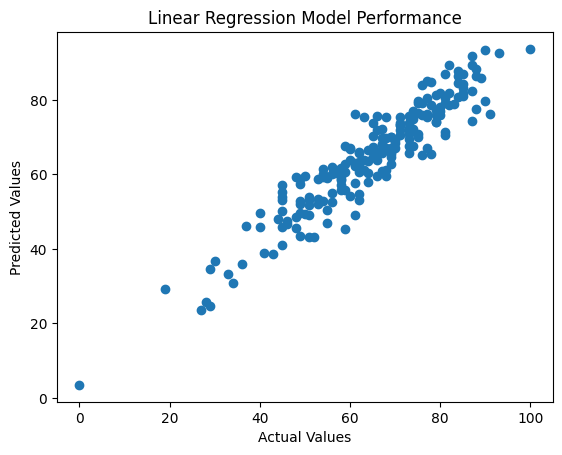

In [45]:
#Plot y_pred and y_test to visualize the performance of the linear regression model.

plt.scatter(y_test, y_pred);
plt.xlabel("Actual Values");
plt.ylabel("Predicted Values");
plt.title("Linear Regression Model Performance");
plt.show();

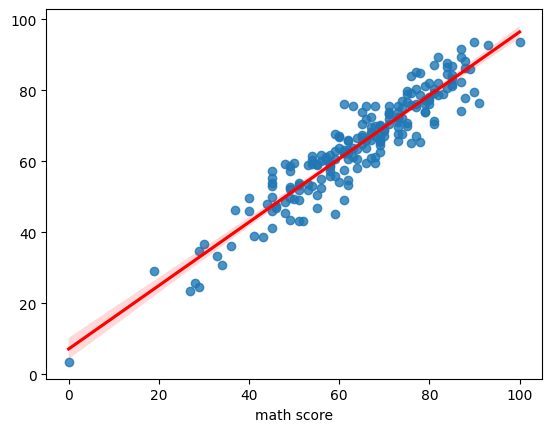

In [46]:
sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"});

In [47]:
#different between actual and predicted values

pred_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred, "Difference": y_test - y_pred})
pred_df

,Actual,Predicted,Difference
521,91,76.28125,14.71875
737,53,58.81250,-5.81250
740,80,77.12500,2.87500
660,74,76.93750,-2.93750
411,84,87.75000,-3.75000
...,...,...,...
408,52,43.21875,8.78125
332,62,62.28125,-0.28125
208,74,67.68750,6.31250
613,65,66.90625,-1.90625
